In [60]:
# Install / import all required libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [61]:
# Load the merged dataset
df = pd.read_csv('Dataset/twitter_dataset.csv')

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (38664, 4)

Columns: ['tweet_id', 'tweet_concept', 'tweet_sentiment', 'tweet']

First few rows:
   tweet_id tweet_concept tweet_sentiment  \
0      2401   Borderlands        Positive   
1      2401   Borderlands        Positive   
2      2401   Borderlands        Positive   
3      2401   Borderlands        Positive   
4      2401   Borderlands        Positive   

                                               tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [62]:
# Drop unnecessary columns
df = df.drop(columns=['tweet_id', 'tweet_concept'], errors='ignore')

# Merge 'Irrelevant' into 'Neutral' to simplify to 3 sentiment classes
df['tweet_sentiment'] = df['tweet_sentiment'].replace('Irrelevant', 'Neutral')

# Remove rows where the tweet text is missing
df = df.dropna(subset=['tweet'])

print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nClass distribution:")
print(df['tweet_sentiment'].value_counts())

Dataset shape after cleaning: (38317, 2)

Class distribution:
tweet_sentiment
Neutral     16673
Positive    11698
Negative     9946
Name: count, dtype: int64


In [63]:
# Define tweet preprocessing with negation handling and sentiment preservation

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Words that carry sentiment meaning — keep them even if they are stopwords
sentiment_words = {
    'not', 'no', 'nor', 'neither', 'never', 'none', 'nobody', 'nothing',
    'but', 'however', 'although', 'though', 'yet', 'still',
    'very', 'really', 'too', 'so', 'quite', 'just',
    'more', 'most', 'less', 'least', 'only', 'same', 'such', 'than'
}
stop_words = stop_words - sentiment_words

# Negation words whose scope should be fused with the following word
NEGATION_WORDS = {'not', 'never', 'no', 'neither', 'nor', 'cannot', 'nothing', 'nobody', 'nowhere'}

def preprocess(text):
    text = str(text).lower()

    # Expand common contractions for better negation detection
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)

    # Remove URLs and usernames
    text = re.sub(r'http\S+|https\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # Keep hashtag words, remove the # symbol
    text = re.sub(r'#', '', text)

    # Collapse repeated characters to max 2 (e.g. "loooove" -> "loove")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Count ! and ? before removing them — used as sentiment markers
    excl = text.count('!')
    ques = text.count('?')
    text = re.sub(r'[^a-z\s]', '', text)
    if excl > 0:
        text += ' exclamation'
    if ques > 0:
        text += ' question'

    # Tokenize
    tokens = text.split()

    # Fuse negation words with the next word (e.g. "not bad" becomes "not_bad")
    fused = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATION_WORDS and i + 1 < len(tokens):
            fused.append(tokens[i] + '_' + tokens[i + 1])
            i += 2
        else:
            fused.append(tokens[i])
            i += 1
    tokens = fused

    # Remove stopwords and lemmatize (negation compounds are kept as-is)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 1
    ]
    return ' '.join(tokens)

# Apply preprocessing to all tweets
df['cleaned_tweet'] = df['tweet'].apply(preprocess)

print("Sample preprocessing results:")
for i in range(3):
    print(f"  Original : {df['tweet'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned_tweet'].iloc[i]}\n")

# Show how negation marking works
print("Negation marking examples:")
examples = [
    "Not bad, but could be better. I'm neutral about it.",
    "This doesn't work at all.",
    "I never liked this product."
]
for e in examples:
    print(f"  Before : {e}")
    print(f"  After  : {preprocess(e)}\n")

Sample preprocessing results:
  Original : im getting on borderlands and i will murder you all ,
  Cleaned  : im getting borderland murder

  Original : I am coming to the borders and I will kill you all,
  Cleaned  : coming border kill

  Original : im getting on borderlands and i will kill you all,
  Cleaned  : im getting borderland kill

Negation marking examples:
  Before : Not bad, but could be better. I'm neutral about it.
  After  : not_bad but could better im neutral

  Before : This doesn't work at all.
  After  : not_work

  Before : I never liked this product.
  After  : never_liked product



In [64]:
# Split into 80% training and 20% test — stratify to preserve class balance
X = df['cleaned_tweet']
y = df['tweet_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training samples : 30653
Test samples     : 7664

Training class distribution:
tweet_sentiment
Neutral     13338
Positive     9358
Negative     7957
Name: count, dtype: int64

Test class distribution:
tweet_sentiment
Neutral     3335
Positive    2340
Negative    1989
Name: count, dtype: int64


In [65]:
# Build TF-IDF feature matrix using word, character, and trigram vectorizers

# Word-level unigrams + bigrams — captures individual words and two-word phrases
tfidf_word = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    norm='l2'
)

# Character n-grams — robust to slang, abbreviations, and misspellings
tfidf_char = TfidfVectorizer(
    analyzer='char',
    max_features=4000,
    ngram_range=(2, 5),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

# Trigrams — captures short phrases and word context
tfidf_trigram = TfidfVectorizer(
    max_features=3000,
    ngram_range=(3, 3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

print("Fitting vectorizers on training data...")
X_train_word    = tfidf_word.fit_transform(X_train)
X_train_char    = tfidf_char.fit_transform(X_train)
X_train_trigram = tfidf_trigram.fit_transform(X_train)

print("Transforming test data...")
X_test_word    = tfidf_word.transform(X_test)
X_test_char    = tfidf_char.transform(X_test)
X_test_trigram = tfidf_trigram.transform(X_test)

# Stack all feature types horizontally into one combined matrix
X_train_combined = hstack([X_train_word, X_train_char, X_train_trigram])
X_test_combined  = hstack([X_test_word,  X_test_char,  X_test_trigram])

print(f"\nTraining feature matrix : {X_train_combined.shape}")
print(f"Test feature matrix     : {X_test_combined.shape}")

Fitting vectorizers on training data...
Transforming test data...

Training feature matrix : (30653, 15000)
Test feature matrix     : (7664, 15000)


In [66]:
# Train the 3 models and evaluate each on the test set

models = {
    # Logistic Regression — consistently strong on TF-IDF text features
    'Logistic Regression': LogisticRegression(
        C=10.0,
        max_iter=2000,
        solver='saga',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # Linear SVM — fast and excellent for high-dimensional sparse data
    'Linear SVM': LinearSVC(
        C=2.0,
        class_weight='balanced',
        max_iter=3000,
        random_state=42
    ),

    # SGD Classifier — stochastic training, very fast on large datasets
    'SGD Classifier': SGDClassifier(
        loss='modified_huber',
        alpha=1e-5,
        max_iter=200,
        tol=1e-4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_combined, y_train)
    y_pred = model.predict(X_test_combined)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'report': classification_report(y_test, y_pred, output_dict=True)
    }
    trained_models[name] = model
    print(f"  {name:25s} -> {acc:.4f} ({acc*100:.2f}%)\n")

Training Logistic Regression...
  Logistic Regression       -> 0.8753 (87.53%)

Training Linear SVM...
  Linear SVM                -> 0.8806 (88.06%)

Training SGD Classifier...
  SGD Classifier            -> 0.8770 (87.70%)



In [67]:
# Rank all models by accuracy and show the best result
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

print("MODEL RANKINGS:")
print("-" * 60)
for rank, (name, result) in enumerate(sorted_results, 1):
    acc = result['accuracy']
    print(f"{rank}. {name:30s} - {acc:.4f} ({acc*100:.2f}%)")

best_model_name = sorted_results[0][0]
best_accuracy   = sorted_results[0][1]['accuracy']

print(f"\n{'='*60}")
print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*60}")

# Full classification report for the best model
print(f"\nCLASSIFICATION REPORT — {best_model_name}:")
print("-" * 60)
print(classification_report(y_test, results[best_model_name]['predictions']))

# Confusion matrix for the best model
print("CONFUSION MATRIX:")
print("-" * 60)
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
print(f"{'':15s} Predicted")
print(f"{'':15s} Neg    Neu    Pos")
print(f"Actual Negative: {cm[0]}")
print(f"       Neutral:  {cm[1]}")
print(f"       Positive: {cm[2]}")

MODEL RANKINGS:
------------------------------------------------------------
1. Linear SVM                     - 0.8806 (88.06%)
2. SGD Classifier                 - 0.8770 (87.70%)
3. Logistic Regression            - 0.8753 (87.53%)

Best Model : Linear SVM
Accuracy   : 0.8806 (88.06%)

CLASSIFICATION REPORT — Linear SVM:
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      1989
     Neutral       0.88      0.90      0.89      3335
    Positive       0.89      0.86      0.87      2340

    accuracy                           0.88      7664
   macro avg       0.88      0.88      0.88      7664
weighted avg       0.88      0.88      0.88      7664

CONFUSION MATRIX:
------------------------------------------------------------
                Predicted
                Neg    Neu    Pos
Actual Negative: [1744  180   65]
       Neutral:  [ 146 2998  191]
       Positive: [  85  248

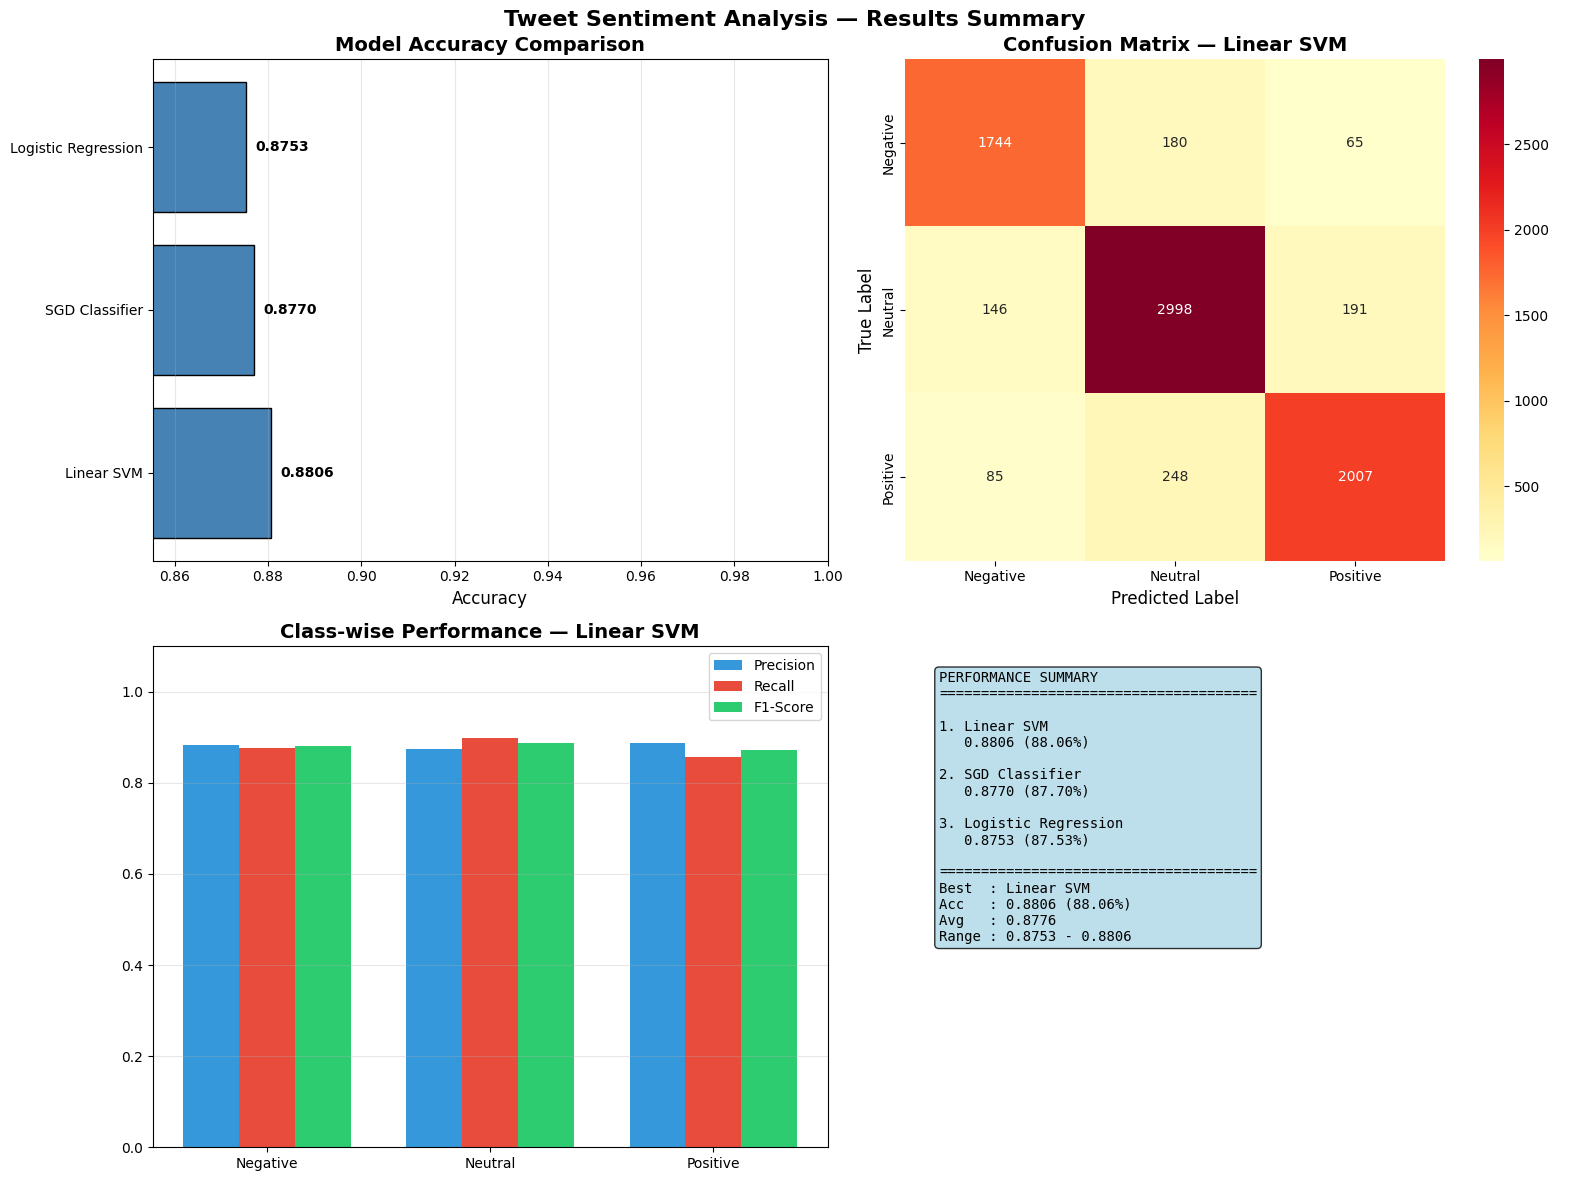

In [68]:
# Visualize model accuracy, confusion matrix, and per-class performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tweet Sentiment Analysis — Results Summary', fontsize=16, fontweight='bold')

model_names = [name for name, _ in sorted_results]
accuracies  = [r['accuracy'] for _, r in sorted_results]

# Bar chart of model accuracies
axes[0, 0].barh(model_names, accuracies, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([min(accuracies) - 0.02, 1.0])
for i, v in enumerate(accuracies):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Confusion matrix heatmap for best model
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=axes[0, 1])
axes[0, 1].set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('True Label', fontsize=12)
axes[0, 1].set_xlabel('Predicted Label', fontsize=12)

# Per-class precision, recall, F1 for best model
report_df  = pd.DataFrame(results[best_model_name]['report']).T
class_perf = report_df.loc[['Negative', 'Neutral', 'Positive'], ['precision', 'recall', 'f1-score']]
x = np.arange(len(class_perf))
w = 0.25
axes[1, 0].bar(x - w, class_perf['precision'], w, label='Precision', color='#3498db')
axes[1, 0].bar(x,     class_perf['recall'],    w, label='Recall',    color='#e74c3c')
axes[1, 0].bar(x + w, class_perf['f1-score'],  w, label='F1-Score',  color='#2ecc71')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(class_perf.index)
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].set_title(f'Class-wise Performance — {best_model_name}', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Summary statistics text panel
summary = "PERFORMANCE SUMMARY\n" + "="*38 + "\n\n"
for rank, (mname, r) in enumerate(sorted_results, 1):
    a = r['accuracy']
    summary += f"{rank}. {mname}\n   {a:.4f} ({a*100:.2f}%)\n\n"
summary += f"{'='*38}\n"
summary += f"Best  : {best_model_name}\n"
summary += f"Acc   : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)\n"
summary += f"Avg   : {np.mean(accuracies):.4f}\n"
summary += f"Range : {np.min(accuracies):.4f} - {np.max(accuracies):.4f}"
axes[1, 1].text(0.05, 0.95, summary, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [69]:
# Set up prediction using the best model detected automatically

# Pick the highest-accuracy model
best_model_name = sorted_results[0][0]
best_model = trained_models[best_model_name]
print(f"Best model : {best_model_name} ({sorted_results[0][1]['accuracy']*100:.2f}%)")

# Find the highest-accuracy model that supports probability output
prob_model, prob_model_name = None, None
for _name, _ in sorted_results:
    if hasattr(trained_models[_name], 'predict_proba'):
        prob_model = trained_models[_name]
        prob_model_name = _name
        break
print(f"Probability model : {prob_model_name}")

def predict_sentiment(tweet_text, show_confidence=True):
    # Preprocess and vectorize the input tweet
    cleaned = preprocess(tweet_text)
    vec = hstack([
        tfidf_word.transform([cleaned]),
        tfidf_char.transform([cleaned]),
        tfidf_trigram.transform([cleaned])
    ])

    # Predict label using the best model
    prediction = best_model.predict(vec)[0]

    if not show_confidence or prob_model is None:
        return prediction, None

    # Return class probabilities from the best model that supports them
    probs = prob_model.predict_proba(vec)[0]
    prob_dict = dict(zip(prob_model.classes_, probs))
    return prediction, prob_dict

Best model : Linear SVM (88.06%)
Probability model : SGD Classifier


In [70]:
# Test the model on example tweets
test_tweets = [
    "I absolutely love this product! Best purchase ever!",
    "This is terrible. Worst experience of my life.",
    "The weather is sunny today.",
    "Just received my order. It's okay, nothing special.",
    "I'm so happy and excited! This is wonderful!",
    "Disappointed and upset. This is not what I expected."
]

print("PREDICTIONS:")
print("-" * 70)

for i, tweet in enumerate(test_tweets, 1):
    pred, probs = predict_sentiment(tweet)
    print(f"\n{i}. {tweet[:65]}{'...' if len(tweet) > 65 else ''}")
    print(f"   Sentiment : {pred}")
    if probs:
        for label, prob in sorted(probs.items(), key=lambda x: x[1], reverse=True):
            print(f"   {label:10s}: {prob:.3f} ({prob*100:.1f}%)")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print("="*70)

PREDICTIONS:
----------------------------------------------------------------------

1. I absolutely love this product! Best purchase ever!
   Sentiment : Positive
   Positive  : 1.000 (100.0%)
   Negative  : 0.000 (0.0%)
   Neutral   : 0.000 (0.0%)

2. This is terrible. Worst experience of my life.
   Sentiment : Negative
   Negative  : 1.000 (100.0%)
   Neutral   : 0.000 (0.0%)
   Positive  : 0.000 (0.0%)

3. The weather is sunny today.
   Sentiment : Neutral
   Neutral   : 0.877 (87.7%)
   Positive  : 0.123 (12.3%)
   Negative  : 0.000 (0.0%)

4. Just received my order. It's okay, nothing special.
   Sentiment : Neutral
   Neutral   : 0.399 (39.9%)
   Positive  : 0.318 (31.8%)
   Negative  : 0.283 (28.3%)

5. I'm so happy and excited! This is wonderful!
   Sentiment : Positive
   Positive  : 1.000 (100.0%)
   Negative  : 0.000 (0.0%)
   Neutral   : 0.000 (0.0%)

6. Disappointed and upset. This is not what I expected.
   Sentiment : Negative
   Negative  : 1.000 (100.0%)
   Neutral  